# 03. 에지 검출 및 윤곽선 기반 특징 분석

Severstal Steel Defect Detection 데이터 기반
- 이진화(Thresholding) 방법 비교
- 에지 검출: Canny, Sobel, Laplacian 등
- 윤곽선(Contour) 특징 추출
- 74차원 특징 벡터 생성 + t-SNE 시각화

In [1]:
import os, sys, cv2, numpy as np, matplotlib.pyplot as plt, warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

from utils.severstal_loader import CLASS_NAMES_KR, CLASS_ABBR
from utils.severstal_preprocessor import PatchDataLoader
from preprocessing.normalization import clahe_equalization
from preprocessing.filters import bilateral_filter
from preprocessing.sharpening import adaptive_sharpen
from preprocessing.morphology import opening
from preprocessing.edge_detection import auto_canny
from utils.filter_utils import compute_edge_density

PATCH_DIR = os.path.join(PROJECT_ROOT, 'data', 'severstal_patches')
OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'outputs', 'figures', 'severstal')
os.makedirs(OUTPUT_DIR, exist_ok=True)

def preprocess(img):
    img = clahe_equalization(img, clip_limit=2.0)
    return img

# 데이터 로드 (소량)
loader = PatchDataLoader(PATCH_DIR)
normal_imgs, _ = loader.load_binary(max_per_class=20, resize=(200, 200), grayscale=True)
normal_imgs = normal_imgs[:20]
defect_imgs, defect_labels = loader.load_defect4(max_per_class=15, resize=(200, 200), grayscale=True)

reps = {'정상': normal_imgs[0]}
for cid in [1,2,3,4]:
    mask = defect_labels == cid
    if mask.sum() > 0:
        reps[CLASS_ABBR[cid]] = defect_imgs[mask][0]

print(f"대표 이미지: {list(reps.keys())}")

대표 이미지: ['정상', 'PS', 'LS', 'SS', 'RD']


## Part 1: 이진화(Thresholding) 분석

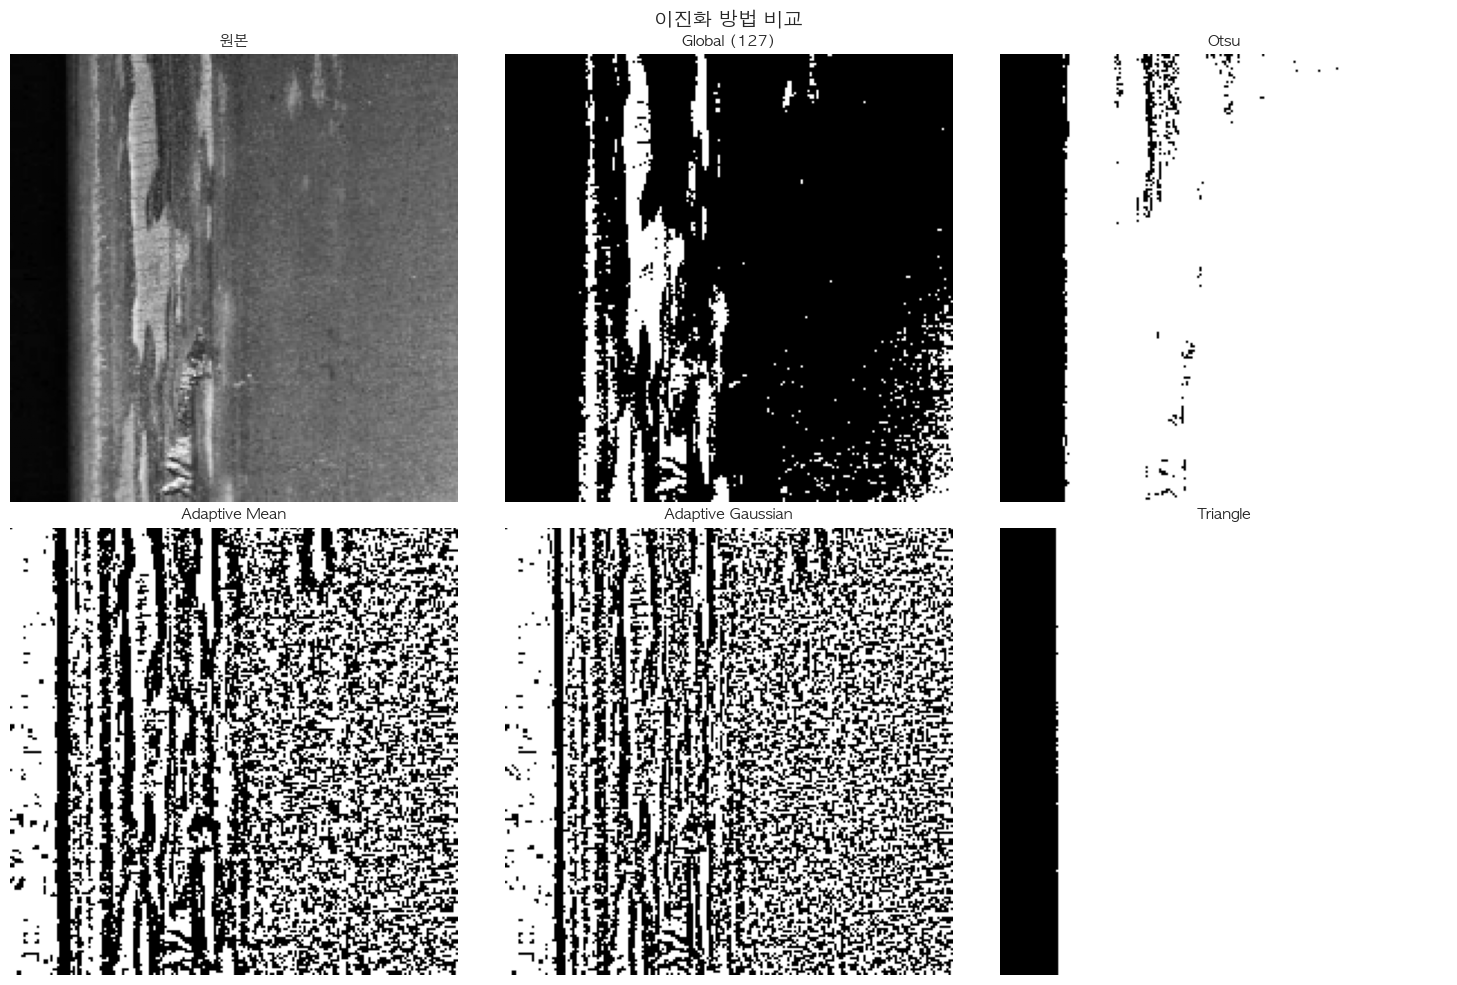

In [2]:
sample = preprocess(list(reps.values())[1])

methods = {
    '원본': sample,
    'Global (127)': cv2.threshold(sample, 127, 255, cv2.THRESH_BINARY)[1],
    'Otsu': cv2.threshold(sample, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1],
    'Adaptive Mean': cv2.adaptiveThreshold(sample, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 2),
    'Adaptive Gaussian': cv2.adaptiveThreshold(sample, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2),
    'Triangle': cv2.threshold(sample, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_TRIANGLE)[1],
}

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, (name, img) in enumerate(methods.items()):
    r, c = i // 3, i % 3
    axes[r, c].imshow(img, cmap='gray')
    axes[r, c].set_title(name, fontsize=11, fontweight='bold')
    axes[r, c].axis('off')

fig.suptitle('이진화 방법 비교', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '03_thresholding.png'), dpi=150, bbox_inches='tight')
plt.show()

## Part 2: 에지 검출 방법 비교

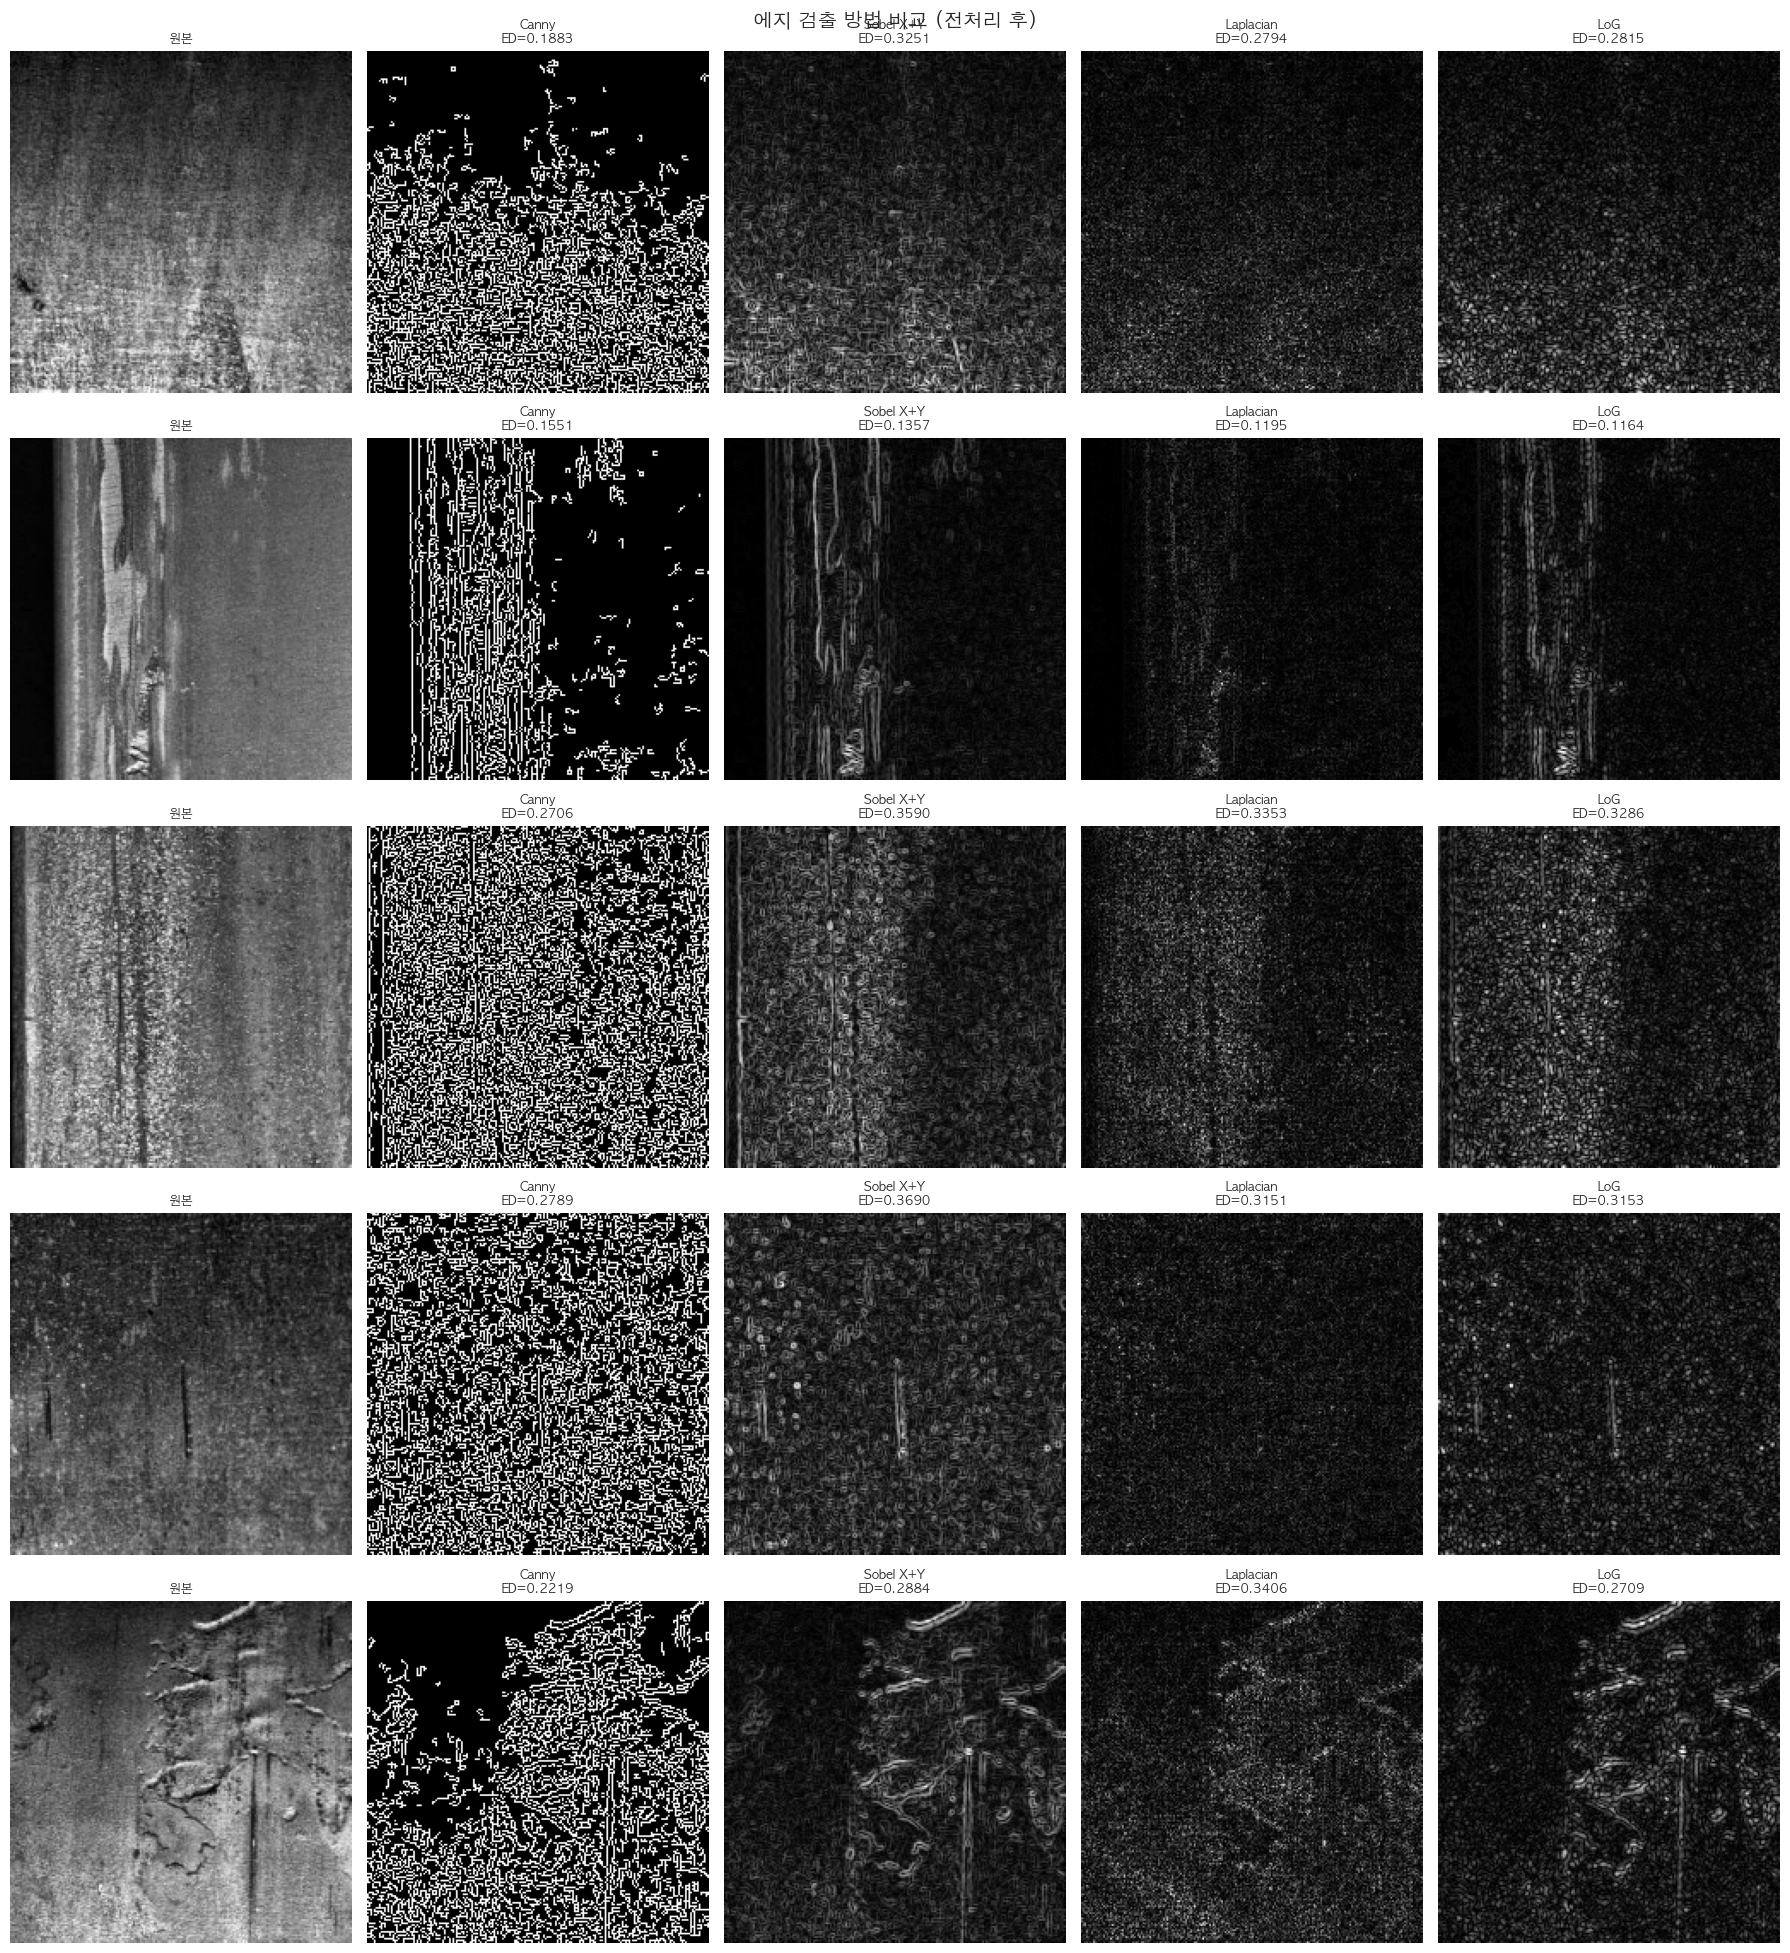

In [3]:
fig, axes = plt.subplots(len(reps), 5, figsize=(18, 4*len(reps)))
edge_methods_names = ['원본', 'Canny', 'Sobel X+Y', 'Laplacian', 'LoG']

for i, (label, raw_img) in enumerate(reps.items()):
    img = preprocess(raw_img)
    
    canny_edge, _, _ = auto_canny(img)
    sobel_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    sobel_mag = np.sqrt(sobel_x**2 + sobel_y**2)
    sobel_mag = np.clip(sobel_mag / sobel_mag.max() * 255, 0, 255).astype(np.uint8)
    laplacian = np.abs(cv2.Laplacian(img, cv2.CV_64F))
    laplacian = np.clip(laplacian / (laplacian.max()+1e-8) * 255, 0, 255).astype(np.uint8)
    blurred = cv2.GaussianBlur(img, (5,5), 0)
    log = np.abs(cv2.Laplacian(blurred, cv2.CV_64F))
    log = np.clip(log / (log.max()+1e-8) * 255, 0, 255).astype(np.uint8)

    edges = [img, canny_edge, sobel_mag, laplacian, log]
    for j, (edge, method_name) in enumerate(zip(edges, edge_methods_names)):
        ed = compute_edge_density(edge) if j > 0 else 0
        axes[i, j].imshow(edge, cmap='gray')
        title = f'{method_name}' if j == 0 else f'{method_name}\nED={ed:.4f}'
        axes[i, j].set_title(title, fontsize=9)
        axes[i, j].axis('off')
    axes[i, 0].set_ylabel(label, fontsize=11, fontweight='bold', rotation=0, ha='right', va='center')

fig.suptitle('에지 검출 방법 비교 (전처리 후)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '03_edge_detection.png'), dpi=150, bbox_inches='tight')
plt.show()

## Part 3: 윤곽선(Contour) 분석

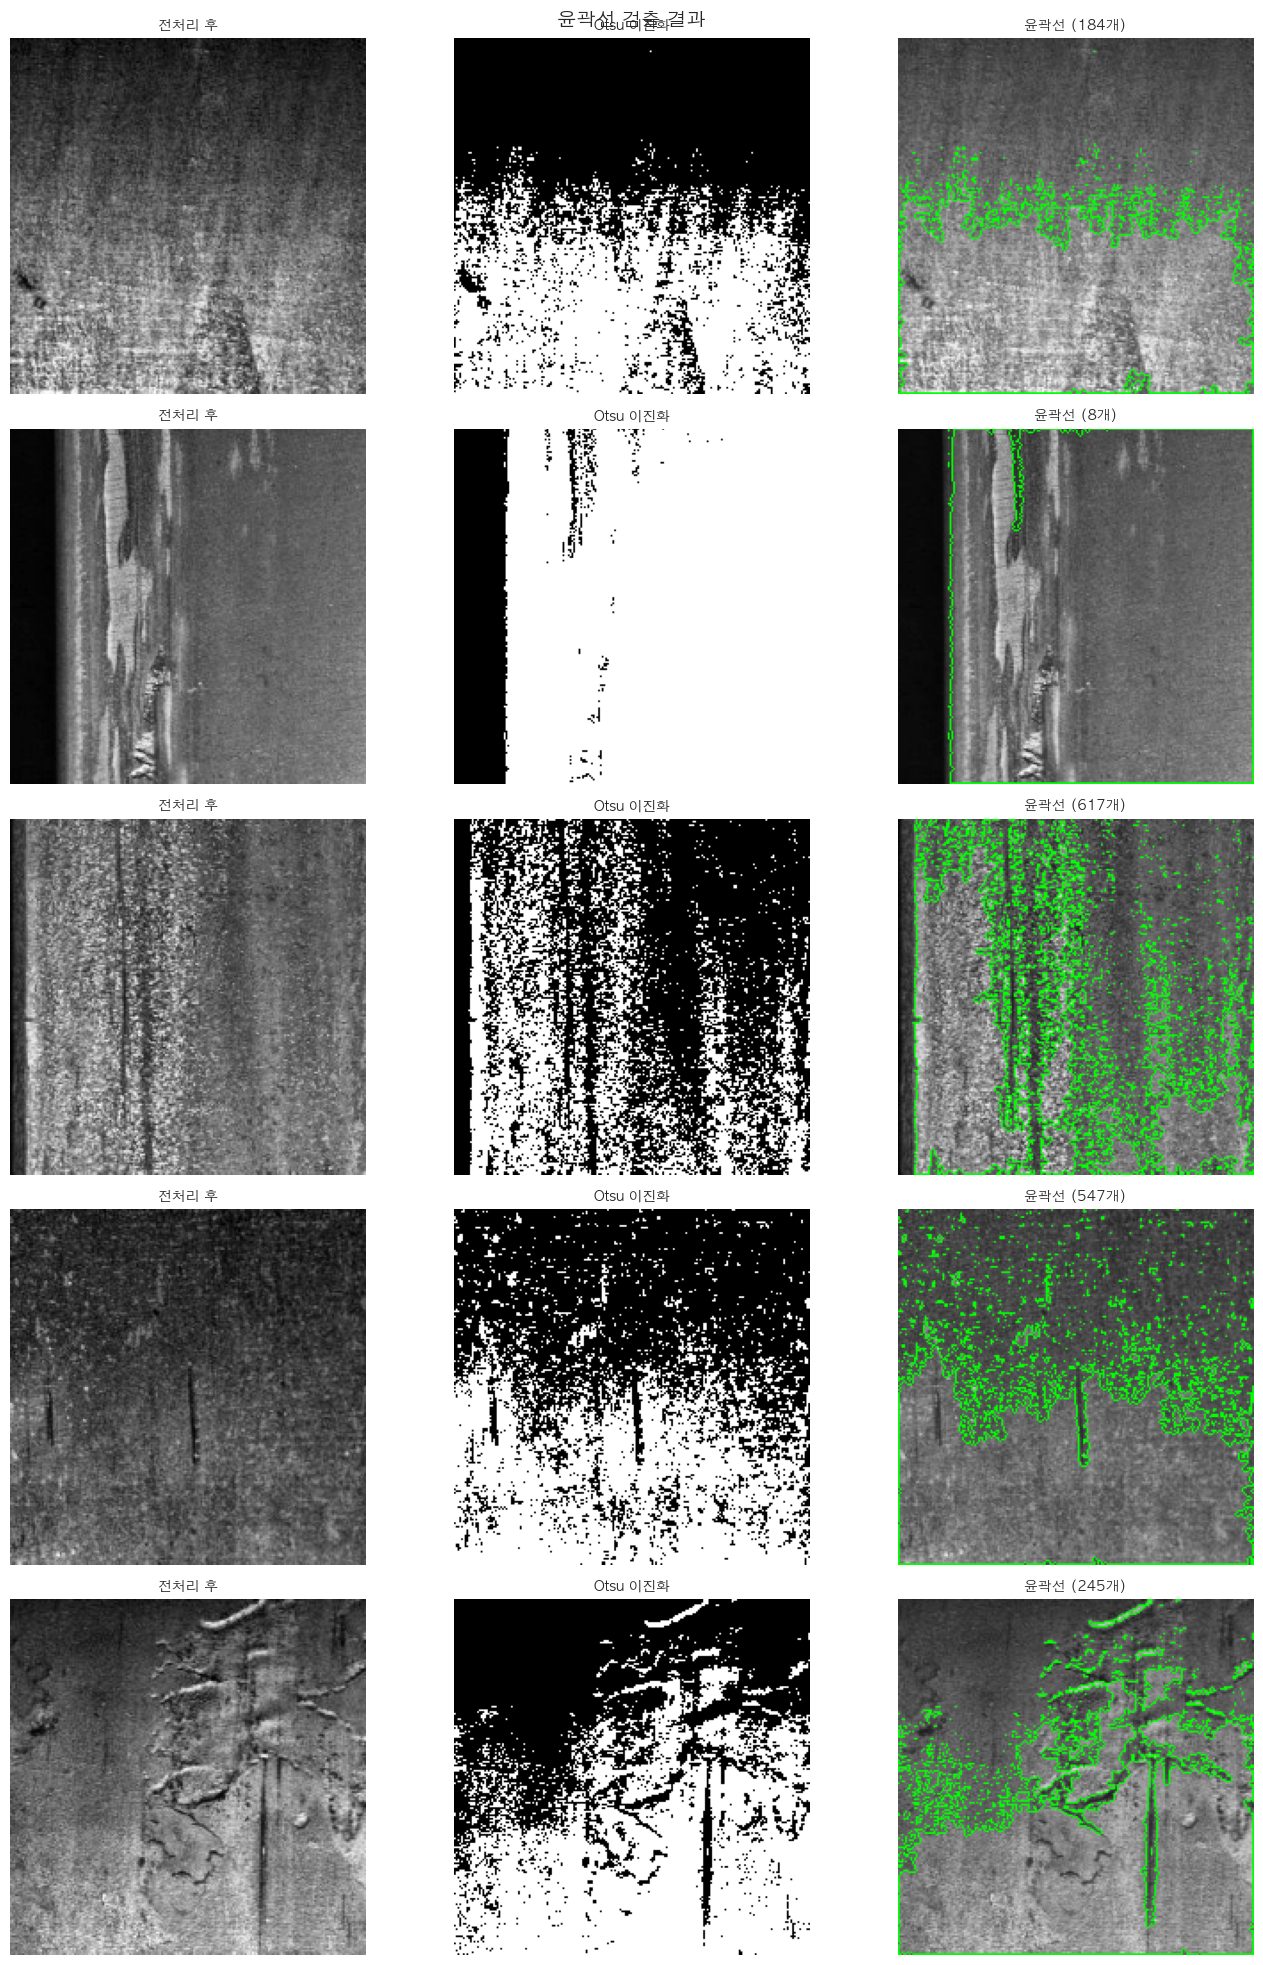

In [4]:
fig, axes = plt.subplots(len(reps), 3, figsize=(14, 4*len(reps)))

for i, (label, raw_img) in enumerate(reps.items()):
    img = preprocess(raw_img)
    _, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    cv2.drawContours(img_rgb, contours, -1, (0, 255, 0), 1)
    
    axes[i, 0].imshow(img, cmap='gray')
    axes[i, 0].set_title('전처리 후', fontsize=10); axes[i, 0].axis('off')
    axes[i, 1].imshow(binary, cmap='gray')
    axes[i, 1].set_title(f'Otsu 이진화', fontsize=10); axes[i, 1].axis('off')
    axes[i, 2].imshow(img_rgb)
    axes[i, 2].set_title(f'윤곽선 ({len(contours)}개)', fontsize=10); axes[i, 2].axis('off')
    axes[i, 0].set_ylabel(label, fontsize=11, fontweight='bold', rotation=0, ha='right', va='center')

fig.suptitle('윤곽선 검출 결과', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '03_contour_detection.png'), dpi=150, bbox_inches='tight')
plt.show()

### 윤곽선 특징 박스플롯

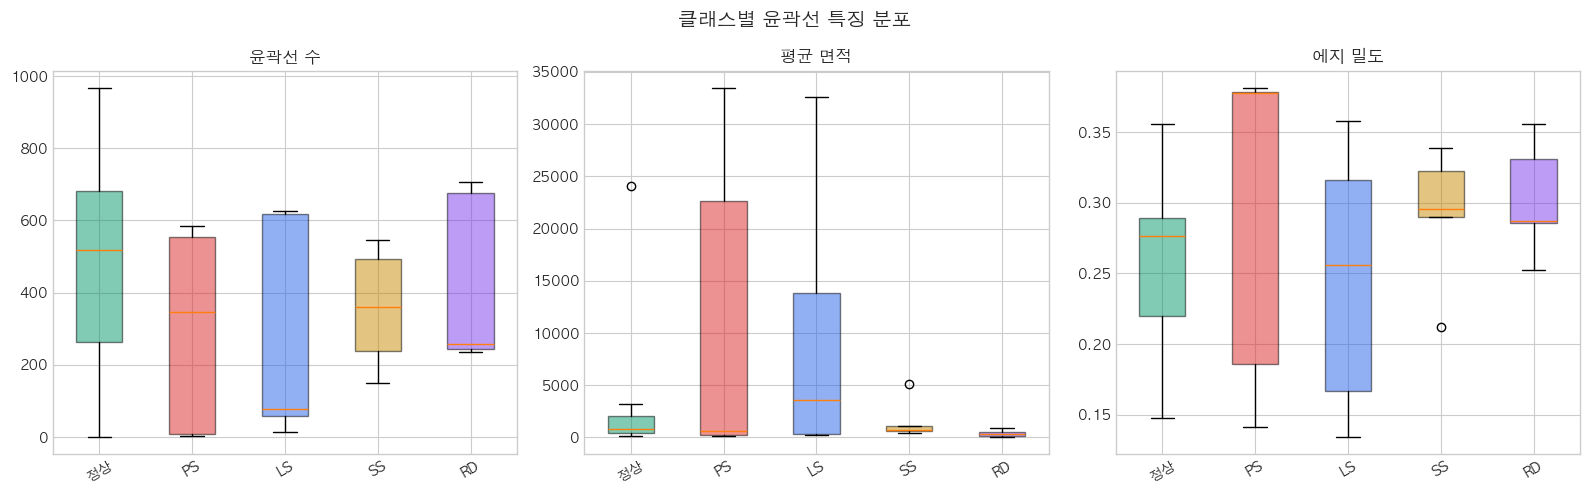

In [5]:
import pandas as pd

contour_data = []
all_imgs = [('정상', img) for img in normal_imgs[:10]]
for cid in [1,2,3,4]:
    mask = defect_labels == cid
    if mask.sum() > 0:
        for img in defect_imgs[mask][:5]:
            all_imgs.append((CLASS_ABBR[cid], img))

for label, raw_img in all_imgs:
    img = preprocess(raw_img)
    _, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    areas = [cv2.contourArea(c) for c in contours if cv2.contourArea(c) > 5]
    contour_data.append({
        '클래스': label,
        '윤곽선 수': len(contours),
        '평균 면적': np.mean(areas) if areas else 0,
        '에지 밀도': compute_edge_density(img),
    })

df_contour = pd.DataFrame(contour_data)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(['윤곽선 수', '평균 면적', '에지 밀도']):
    classes = df_contour['클래스'].unique()
    data = [df_contour[df_contour['클래스']==c][col].values for c in classes]
    bp = axes[i].boxplot(data, labels=classes, patch_artist=True)
    colors = ['#059669', '#dc2626', '#2563eb', '#ca8a04', '#7c3aed']
    for patch, color in zip(bp['boxes'], colors[:len(classes)]):
        patch.set_facecolor(color)
        patch.set_alpha(0.5)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=30)

fig.suptitle('클래스별 윤곽선 특징 분포', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '03_contour_features_boxplot.png'), dpi=150, bbox_inches='tight')
plt.show()

## Part 4: 특징 벡터 추출 및 시각화

HOG + LBP + Pixel Stats + Contour + Edge 특징을 추출하고 t-SNE로 클래스 분리도를 확인합니다.  
(64×64 리사이즈 기준 약 1,944차원)

In [6]:
from features.feature_pipeline import FeaturePipeline

# 특징 추출용 데이터 (64x64 리사이즈 → 차원 축소)
print("[특징 추출용 데이터 로드 중...]")
loader_feat = PatchDataLoader(PATCH_DIR)
norm_feat, _ = loader_feat.load_binary(max_per_class=20, resize=(64, 64), grayscale=True)
norm_feat = norm_feat[:20]
def_feat, def_lbl = loader_feat.load_defect4(max_per_class=10, resize=(64, 64), grayscale=True)

all_feature_imgs = list(norm_feat[:15])
feature_labels = [0] * 15
for cid in [1, 2, 3, 4]:
    mask = def_lbl == cid
    if mask.sum() > 0:
        imgs = def_feat[mask][:8]
        all_feature_imgs.extend(list(imgs))
        feature_labels.extend([cid] * len(imgs))

all_feature_imgs = np.array(all_feature_imgs)
feature_labels = np.array(feature_labels)

pipeline = FeaturePipeline()
X, _ = pipeline.extract_batch(all_feature_imgs)
print(f"특징 벡터 shape: {X.shape} ({X.shape[1]}차원)")
print(f"샘플 수: {len(X)} (정상 15 + 결함 {len(X)-15})")

[특징 추출용 데이터 로드 중...]


  특징 추출: 47/47 (100%)
특징 벡터 shape: (47, 1944) (1944차원)
샘플 수: 47 (정상 15 + 결함 32)


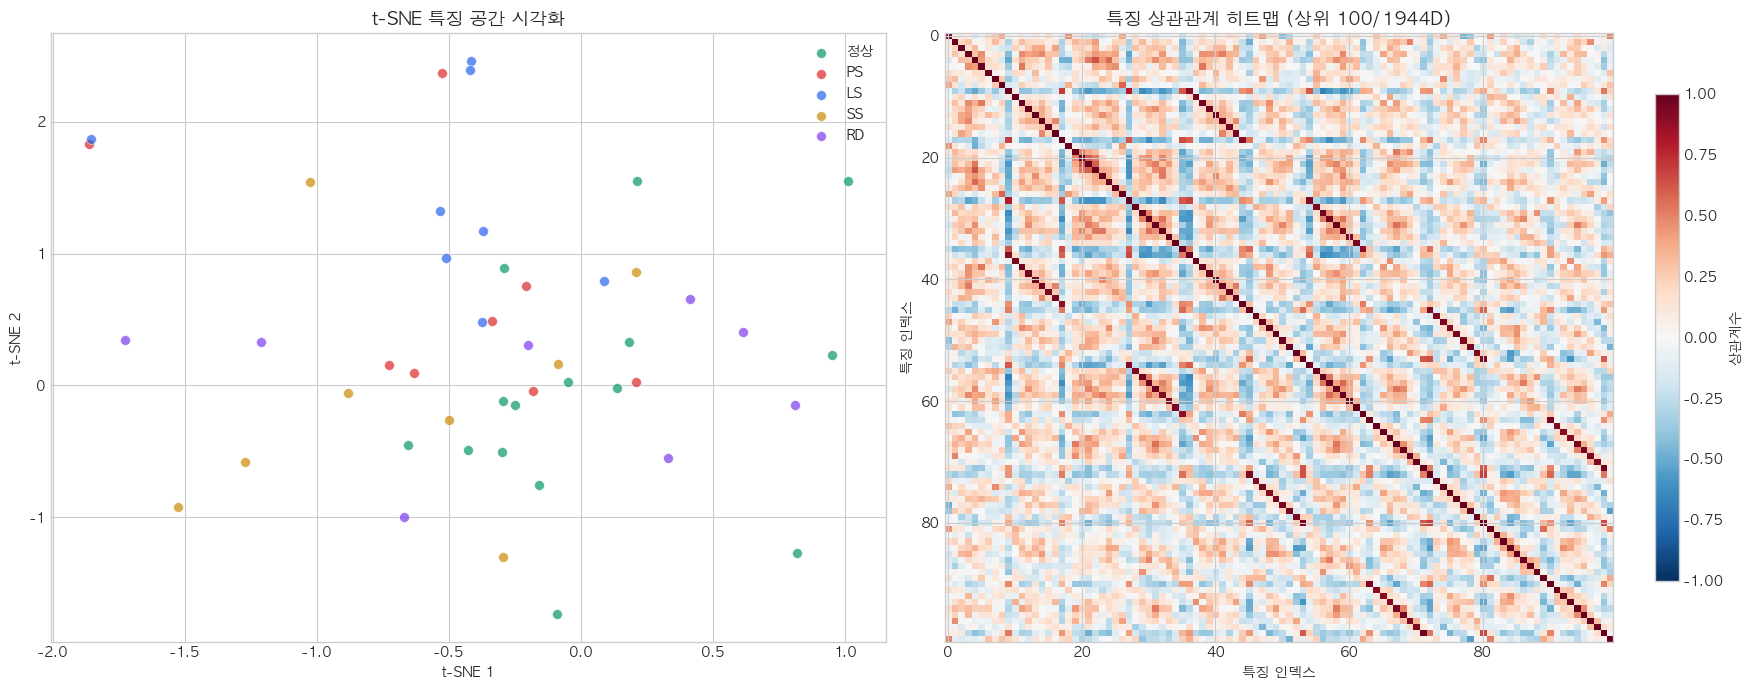

전체 특징 차원: 1944D
높은 상관관계 쌍 (|r|>0.8): 2244개
→ 정상/결함 간 t-SNE 분리도 확인 → ML 분류 가능성 입증


In [7]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(X)-1))
X_tsne = tsne.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# t-SNE
colors = {0: '#059669', 1: '#dc2626', 2: '#2563eb', 3: '#ca8a04', 4: '#7c3aed'}
label_names = {0: '정상', 1: 'PS', 2: 'LS', 3: 'SS', 4: 'RD'}
for lbl in sorted(set(feature_labels)):
    mask = feature_labels == lbl
    axes[0].scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=colors.get(lbl, '#333'),
               label=label_names.get(lbl, str(lbl)), alpha=0.7, s=50, edgecolors='white', linewidth=0.5)
axes[0].set_title('t-SNE 특징 공간 시각화', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].set_xlabel('t-SNE 1'); axes[0].set_ylabel('t-SNE 2')

# 특징 상관관계 히트맵 (상위 100차원만 표시)
n_show = min(100, X.shape[1])
corr = np.corrcoef(X[:, :n_show].T)
im = axes[1].imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
axes[1].set_title(f'특징 상관관계 히트맵 (상위 {n_show}/{X.shape[1]}D)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('특징 인덱스'); axes[1].set_ylabel('특징 인덱스')
plt.colorbar(im, ax=axes[1], label='상관계수', shrink=0.8)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '03_tsne_and_correlation.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')

# 전체 특징에 대한 통계
corr_full = np.corrcoef(X.T)
high_corr = np.sum(np.abs(corr_full) > 0.8) - X.shape[1]
print(f"전체 특징 차원: {X.shape[1]}D")
print(f"높은 상관관계 쌍 (|r|>0.8): {high_corr // 2}개")
print("→ 정상/결함 간 t-SNE 분리도 확인 → ML 분류 가능성 입증")

## 결론

### 핵심 발견
1. **에지 검출**: Auto Canny가 파라미터 자동 설정으로 가장 실용적
2. **윤곽선 특징**: 정상 vs 결함 간 윤곽선 수, 면적, 에지 밀도에서 차이 확인
3. **특징 벡터**: HOG+LBP+Stats+Contour+Edge → 약 1,944차원 벡터로 클래스 정보 인코딩
4. **t-SNE**: 정상/결함 간 분리 패턴 확인 → ML 분류 가능성 입증
5. **상관관계**: 일부 높은 상관 특징 존재 → 차원 축소(PCA) 여지

→ 다음 노트북(04)에서 이 특징 벡터를 활용한 ML 분류 모델을 학습합니다.